# Binarization - 2値化

## 1. 2値化のステップ

### 1.1 画像の読み込み

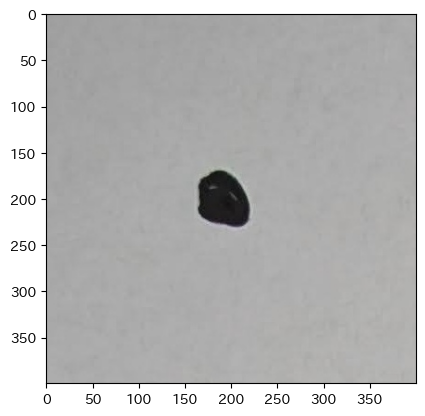

In [1]:
import cv2 as cv
import matplotlib.pyplot as plt

image = cv.imread('data/single_dot_image01.jpg')  # 読み込み
plt.imshow(cv.cvtColor(image, cv.COLOR_BGR2RGB))  # 表示。BGR -> RGBへ変換

### 1.2 グレースケール化 (1チャネル化)

gray_image.shape=(400, 400)


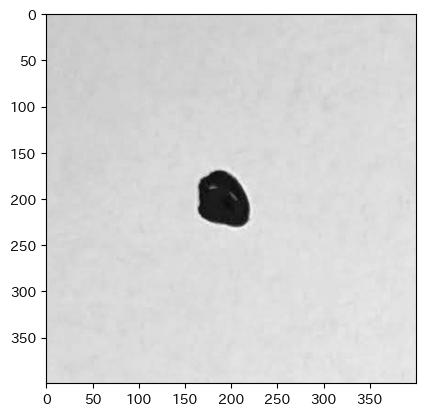

In [2]:
import cv2 as cv
import matplotlib.pyplot as plt

gray_image = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
print(f"{gray_image.shape=}")
cv.imwrite(f'./data/single_dot_image_gray01.jpg', gray_image)
plt.imshow(gray_image, cmap='gray')  # 表示。グレースケールで表示

### 1.3 色分布の分析 - 単一ライン

In [3]:
import numpy as np
import plotly.graph_objects as go

def plot_single_channel_color_values_along_row(single_channel_image, height_index):
    """単色画像において指定した行の色の値をプロットする関数
    Args:
        single_channel_image (numpy.ndarray): 単一チャンネル画像
        height_index (int): プロットする行のインデックス
    """
    width = single_channel_image.shape[1]  # 画像の幅

    trace1 = go.Scatter(
        x=np.arange(width),  # 0から幅-1までのピクセル位置
        y=single_channel_image[height_index, :],  # 赤の成分
        mode='lines',
        name='Red',
        line=dict(color='red')
    )

    fig = go.Figure(data=[trace1])
    fig.update_layout(title=f'Color Values Along RowIndex={height_index}',
                    xaxis_title='Pixel Position',
                    yaxis_title='Color Intensity (0-255)')
    fig.show()

In [4]:
plot_single_channel_color_values_along_row(gray_image, height_index=199)

### 1.4 色分布の分析 - ヒストグラム

In [5]:
# グレースケール画像の形状を確認
gray_image.shape

(400, 400)

In [6]:
# グレースケール画像の内容を確認
gray_image

array([[160, 161, 160, ..., 170, 170, 171],
       [160, 160, 160, ..., 171, 171, 171],
       [159, 160, 160, ..., 171, 171, 171],
       ...,
       [172, 173, 174, ..., 180, 180, 180],
       [172, 173, 174, ..., 181, 181, 181],
       [172, 173, 173, ..., 181, 181, 181]], shape=(400, 400), dtype=uint8)

In [7]:
# グレースケール画像を1次元配列に変換して形状を確認
np.ravel(gray_image).shape

(160000,)

In [8]:
# グレースケール画像を1次元配列に変換して内容を確認
np.ravel(gray_image)

array([160, 161, 160, ..., 181, 181, 181], shape=(160000,), dtype=uint8)

In [9]:
# 画素値のヒストグラムを作成 (matplotlib)
import numpy as np
import matplotlib.pyplot as plt

def plot_histogram_matplotlib(single_channel_image: np.ndarray):
    """単色画像のヒストグラムをmatplotlibでプロットする関数
    Args:
        single_channel_image (numpy.ndarray): 単一チャンネル画像
    """
    plt.hist(single_channel_image.ravel(), bins=256, range=(0, 255), color='gray')
    plt.title('Histogram of Grayscale Image')
    plt.xlabel('Pixel Value')
    plt.ylabel('Frequency')
    plt.show()

In [10]:
# 画素値のヒストグラムを作成 (plotly)
import plotly.graph_objects as go

def plot_histogram_plotly(single_channel_image: np.ndarray):
    """単色画像のヒストグラムをplotlyでプロットする関数
    Args:
        single_channel_image (numpy.ndarray): 単一チャンネル画像
    """
    fig = go.Figure(data=[go.Histogram(x=single_channel_image.ravel(), nbinsx=256)])
    fig.update_layout(
        title='Histogram of Grayscale Image',
        xaxis_title='Pixel Value',
        yaxis_title='Frequency'
    )
    fig.show()

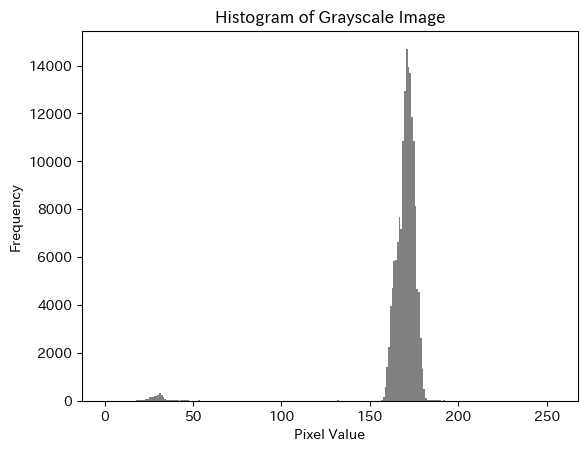

In [11]:
plot_histogram_matplotlib(gray_image)
plot_histogram_plotly(gray_image)

### 1.5 2値化 (閾値 手動調整)

binary_image.shape=(400, 400)


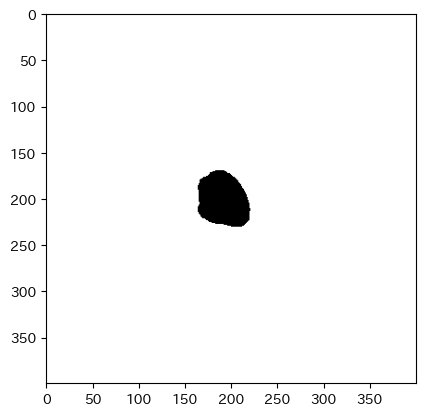

In [12]:
import cv2 as cv
import matplotlib.pyplot as plt

_, binary_image = cv.threshold(gray_image, 127, 255, cv.THRESH_BINARY)
print(f"{binary_image.shape=}")
plt.imshow(binary_image, cmap='gray')  # 表示。二値化画像をグレースケールで表示

## 2. 他の画像を2値化 (閾値 手動調整)

In [13]:
import cv2 as cv
import matplotlib.pyplot as plt

def binarize_image(image_path: str, threshold: int):
    """画像を読み込み、グレースケール変換、二値化して表示する関数
    Args:
        image_path (str): 画像のパス
        threshold (int): 二値化の閾値
    """
    image = cv.imread(image_path)  # 画像読み込み
    plt.imshow(cv.cvtColor(image, cv.COLOR_BGR2RGB))  # 表示。BGR -> RGBへ変換
    plt.show()

    gray_image = cv.cvtColor(image, cv.COLOR_BGR2GRAY)  # グレースケール変換
    _, binary_image = cv.threshold(gray_image, threshold, 255, cv.THRESH_BINARY)  # 二値化
    plt.imshow(binary_image, cmap='gray')  # 表示。二値化画像をグレースケールで表示
    plt.show()

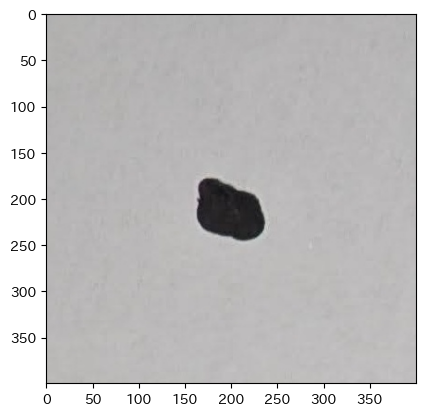

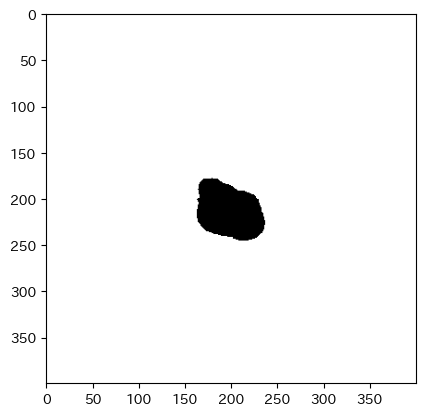

In [14]:
binarize_image('data/single_dot_image02.jpg', threshold=127)

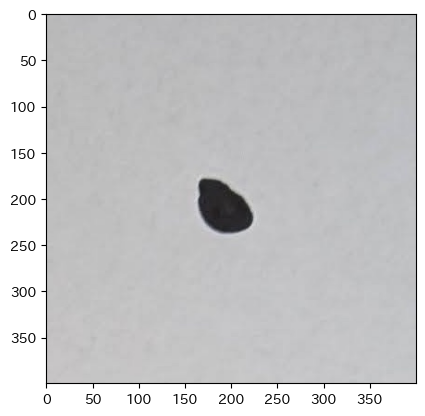

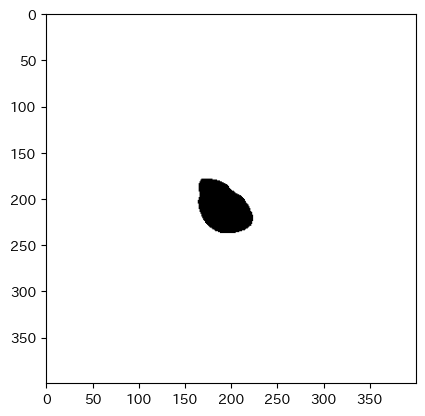

In [15]:
binarize_image('data/single_dot_image03.jpg', threshold=127)

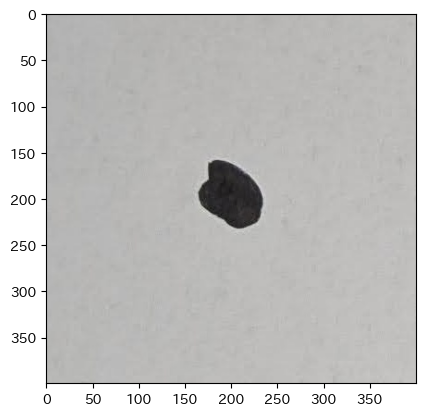

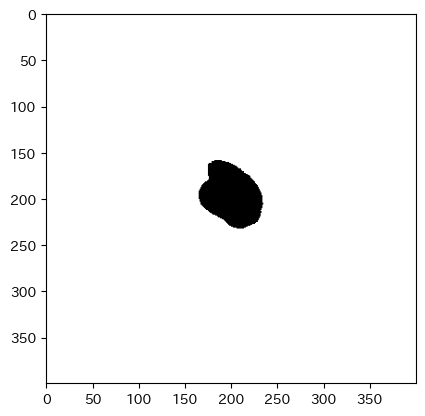

In [16]:
binarize_image('data/single_dot_image04.jpg', threshold=127)

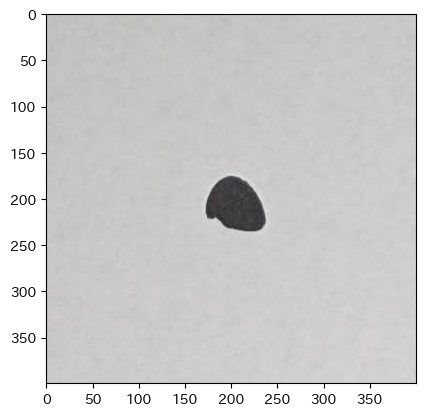

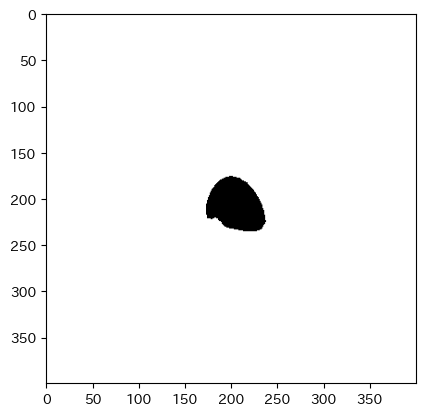

In [17]:
binarize_image('data/single_dot_image05.jpg', threshold=127)

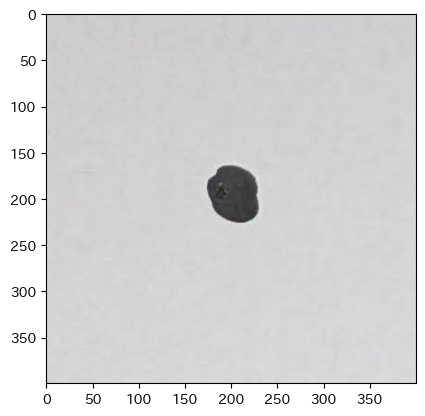

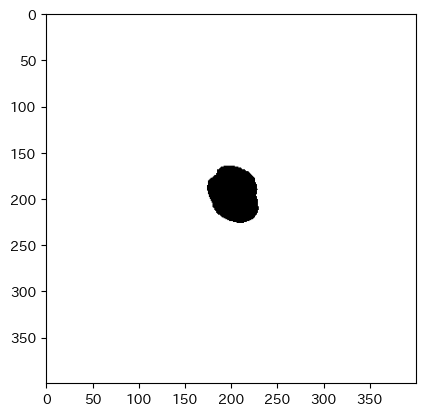

In [18]:
binarize_image('data/single_dot_image06.jpg', threshold=127)

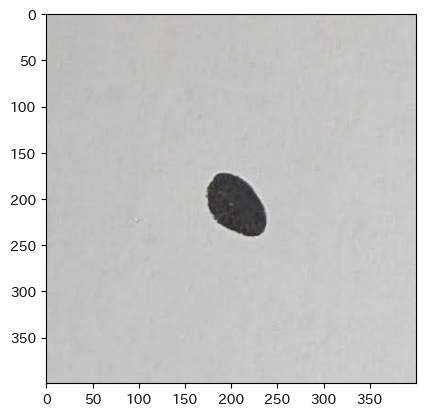

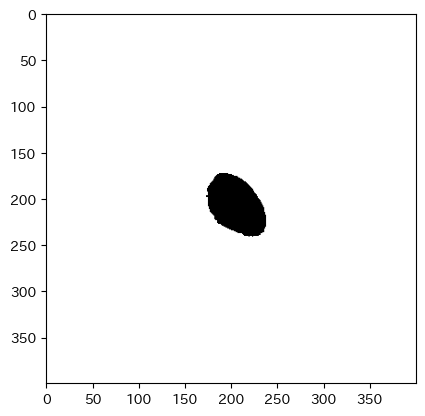

In [19]:
binarize_image('data/single_dot_image07.jpg', threshold=127)

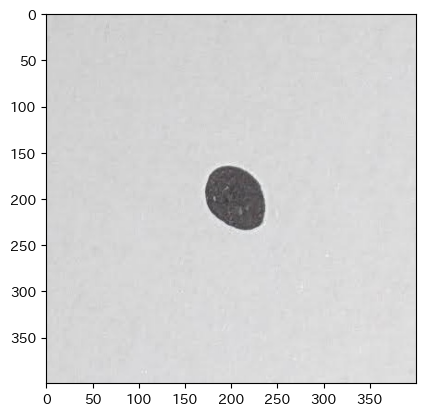

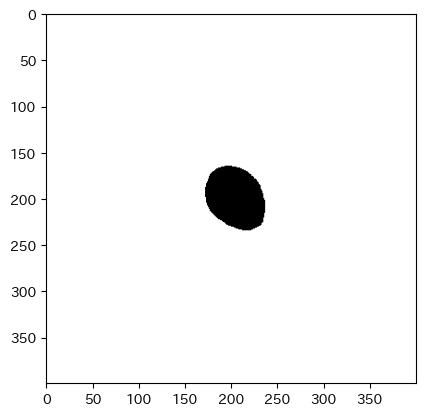

In [20]:
binarize_image('data/single_dot_image08.jpg', threshold=170)

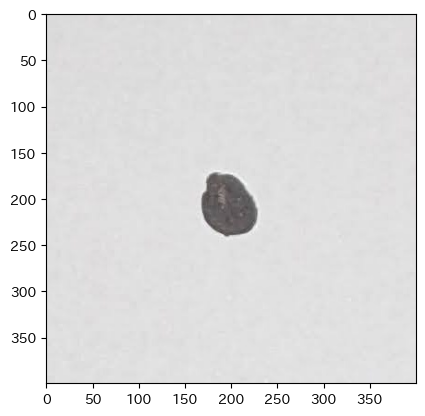

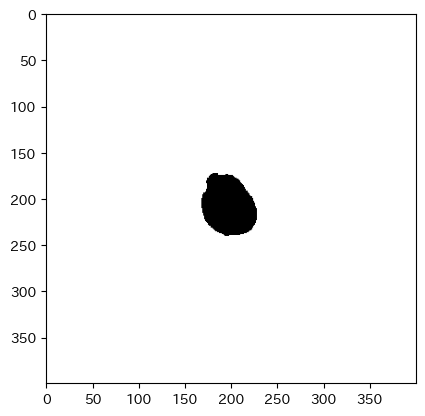

In [21]:
binarize_image('data/single_dot_image09.jpg', threshold=160)

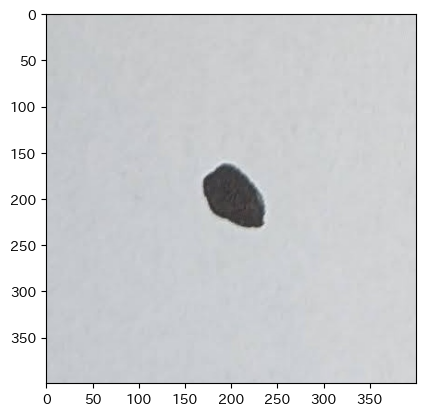

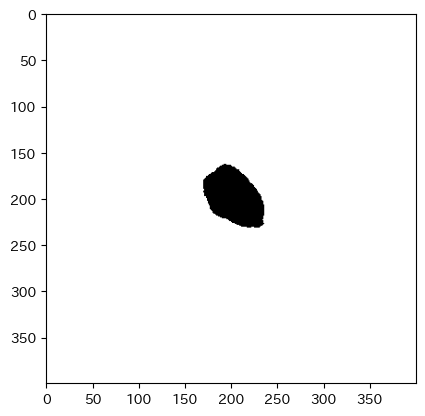

In [22]:
binarize_image('data/single_dot_image10.jpg', threshold=127)

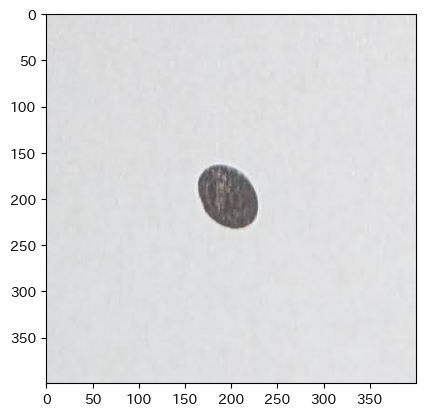

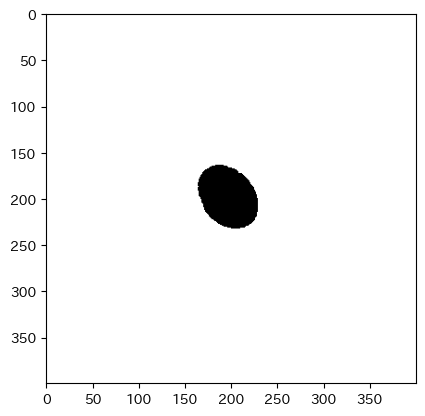

In [23]:
binarize_image('data/single_dot_image11.jpg', threshold=170)

In [24]:
gray_image_12 = cv.cvtColor(cv.imread('data/single_dot_image12.jpg'), cv.COLOR_BGR2GRAY)
plot_single_channel_color_values_along_row(gray_image_12, height_index=199)

In [25]:
plot_histogram_plotly(gray_image_12)

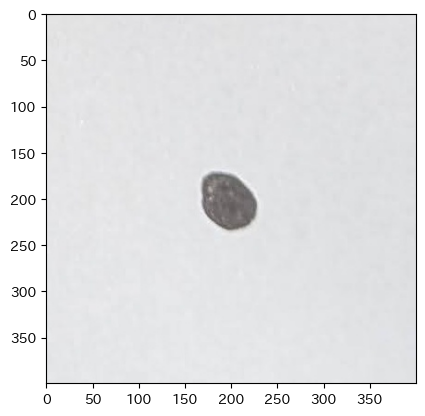

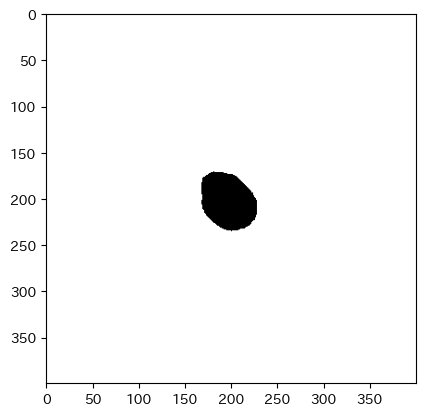

In [26]:
binarize_image('data/single_dot_image12.jpg', threshold=190)

## 3. 2値化の閾値を自動調整

参考[1] OpenCV-Python Tutorials 1 documentation 画像のしきい値処理<br>
https://labs.eecs.tottori-u.ac.jp/sd/Member/oyamada/OpenCV/html/py_tutorials/py_imgproc/py_thresholding/py_thresholding.html

参考[2] OpenCV - Image Thresholding<br>
https://docs.opencv.org/4.x/d7/d4d/tutorial_py_thresholding.html

参考[3] OpenCV - threshold<br>
https://docs.opencv.org/4.x/d7/d1b/group__imgproc__misc.html#gae8a4a146d1ca78c626a53577199e9c57

### 3.1 単一画像で確認

In [27]:
import cv2 as cv
import matplotlib.pyplot as plt

def binarize_image_with_otsu_algorithm(image_path: str, show_images: bool = True):
    """画像を読み込み、グレースケール変換、二値化して表示する関数
    Args:
        image_path (str): 画像のパス
        show_images (bool): 画像を表示するかどうか
    
    Returns:
        binary_image (numpy.ndarray): 二値化された画像
    """
    image = cv.imread(image_path)  # 画像読み込み
    if show_images:
        plt.imshow(cv.cvtColor(image, cv.COLOR_BGR2RGB))  # 表示。BGR -> RGBへ変換
        plt.show()

    blur = cv.GaussianBlur(image,(5,5),0)
    if show_images:
        plt.imshow(blur, cmap='gray')  # Gaussianフィルタをかけた画像をグレースケールで表示。
        plt.show()

    gray_image = cv.cvtColor(blur, cv.COLOR_BGR2GRAY)  # グレースケール変換
    ret, binary_image = cv.threshold(gray_image, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)  # 大津の二値化
    if show_images:
        print(f"Otsu's threshold value: {ret}")
        plt.imshow(binary_image, cmap='gray')  # 表示。二値化画像をグレースケールで表示
        plt.show()
    
    return binary_image

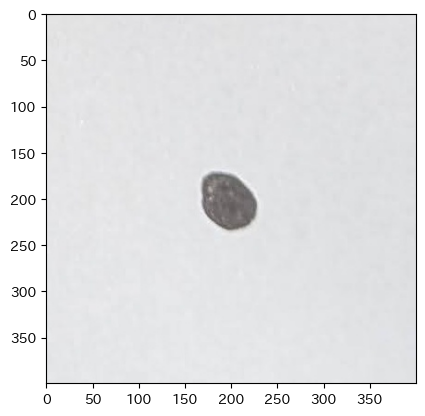

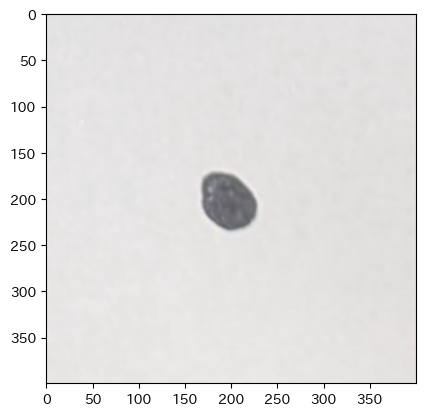

Otsu's threshold value: 171.0


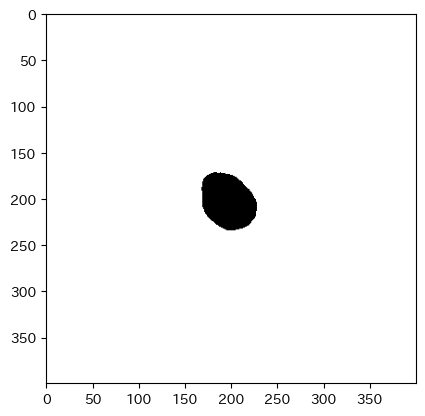

array([[255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       ...,
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255]], shape=(400, 400), dtype=uint8)

In [28]:
binarize_image_with_otsu_algorithm('data/single_dot_image12.jpg', show_images=True)

### 3.2 複数画像の一括変換

In [29]:
suffix_list = [f"{x:02}" for x in range(1, 13)]
binarized_image_list = []
for suffix in suffix_list:
    image_name = f'single_dot_image{suffix}'
    print(f"Processing {image_name}.jpg")
    binarized_image = binarize_image_with_otsu_algorithm(f'data/{image_name}.jpg', show_images=False)
    binarized_image_list.append((image_name, binarized_image))

Processing single_dot_image01.jpg
Processing single_dot_image02.jpg
Processing single_dot_image03.jpg
Processing single_dot_image04.jpg
Processing single_dot_image05.jpg
Processing single_dot_image06.jpg
Processing single_dot_image07.jpg
Processing single_dot_image08.jpg
Processing single_dot_image09.jpg
Processing single_dot_image10.jpg
Processing single_dot_image11.jpg
Processing single_dot_image12.jpg


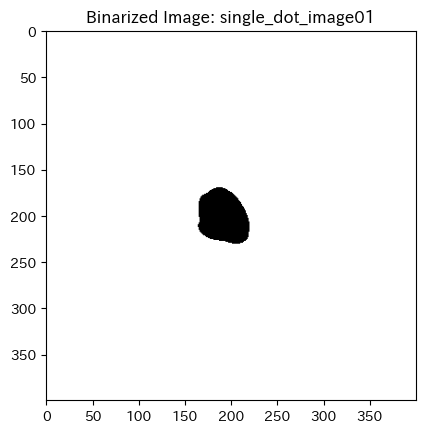

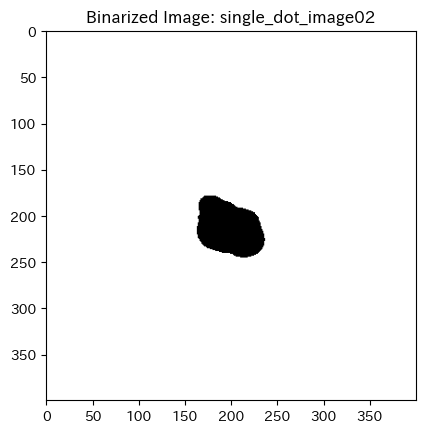

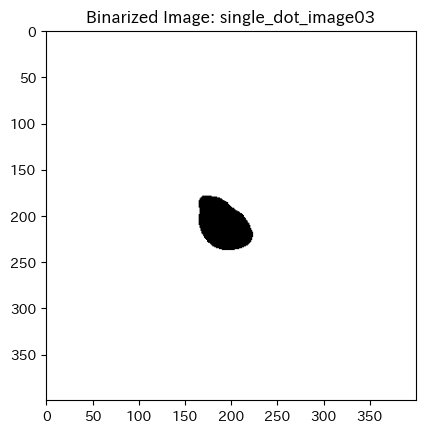

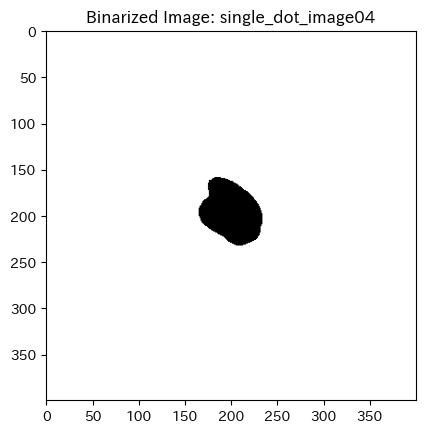

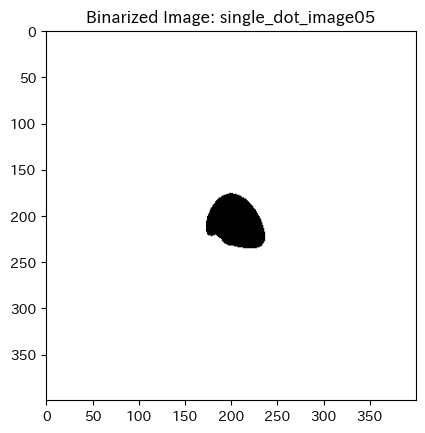

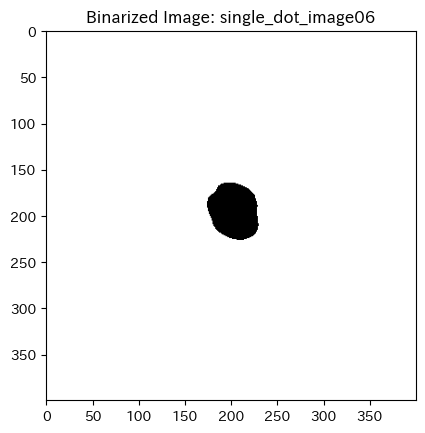

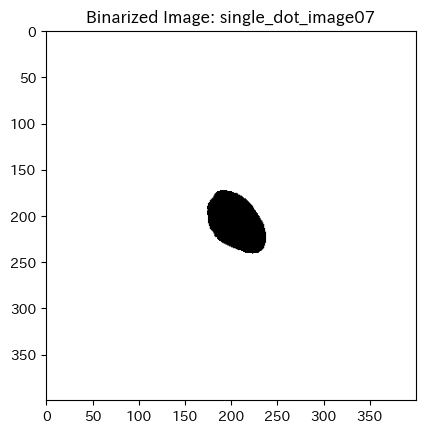

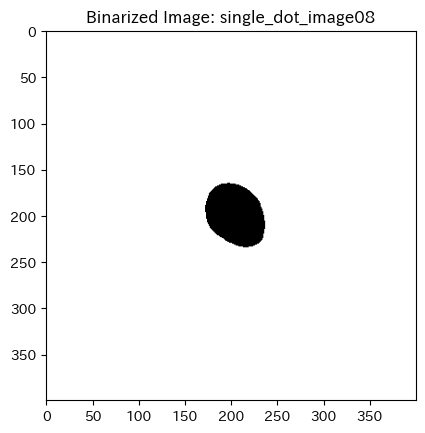

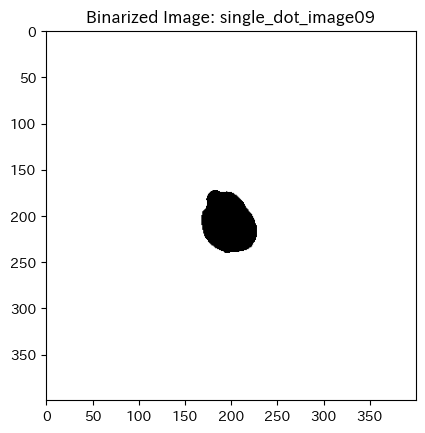

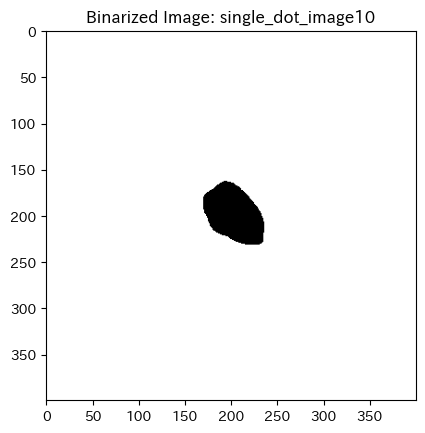

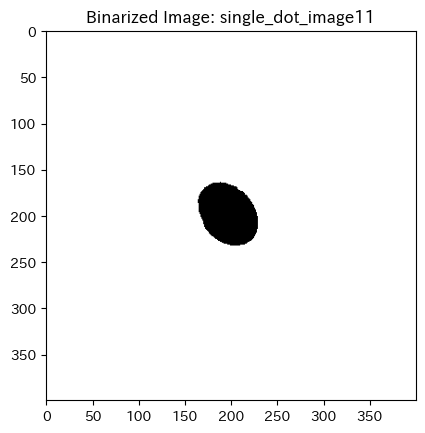

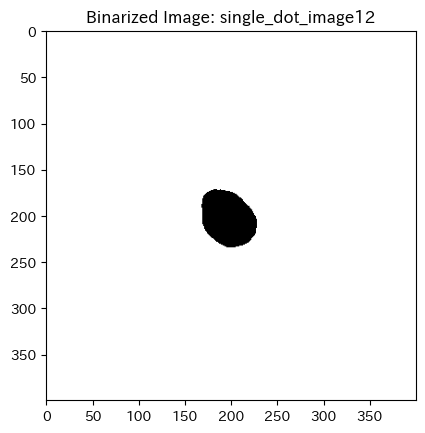

In [30]:
for image_name, binarized_image in binarized_image_list:
    plt.imshow(binarized_image, cmap='gray')
    plt.title(f'Binarized Image: {image_name}')
    plt.show()